In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
panel = pd.read_parquet("../data/pipeline/panel.parquet")
panel.head()

In [ ]:
# an alternative to panda's insert(args) since it throws an error if the column already exists
# same logic but instead of df.insert, we use insert_or_replace(df, args)
def insert_or_replace(df, position, name, values):
    if name in df.columns:
        df.drop(columns=name, inplace=True)
    df.insert(position, name, values)

# gives the position to insert columns after a specified column
from typing import cast

# for some reason pylance never lets me use .get_loc() + 1
def nextpos(df, col:str)->int:
    pos = cast(int, df.columns.get_loc(col))
    return pos + 1

# if i ever need to swap cols
def swapcolumns(df, col1:str, col2:str):
    columns = list(df.columns)
    new = columns.index(col1) 
    old = columns.index(col2)

    columns[new], columns[old] = columns[old], columns[new]

    df = df[columns]
    return df


In [18]:
# a master function that builds a pipeline for plotting decay curves for any panel thrown at it
# i made this as individual cells first but just in case we want to keep plotting decay curves
# for diff panel subets
def compute_decay_curve(data, time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf], 
                        time_labels = [
                        "0-1 day",
                        "1-2 days",
                        "2-4 days",
                        "4-7 days",
                        "1-2 weeks",
                        "2-4 weeks",
                        "1-2 months",
                        "2-4 months",
                        ">4 months"], 
                        label="", flip = True, both = True, size = (10,6)):
    """
    Runs the full decay-curve pipeline on whatever panel-shaped dataframe
    is passed in as `data`. Assumes `data` already has the columns
    ttr_bin, price_bins, yes_outcomes, and a market_id index level --
    i.e. it expects a slice of the same panel structure already
    built.

    `label` is just a string used in the plot titles, so you can tell
    which subset you're looking at (e.g. "full panel" vs "cohort").

    Returns: (decay, entropy_Y) -- the decay dataframe and the baseline
    entropy, in case you want to inspect the numbers directly instead
    of just looking at the plots.

    Flip: Reverse the order of ttr_bins

    Both: Print graphs of both conditional entropy and mutual information
    """

    p_yes = data.groupby("market_id")["yes_outcomes"].first().mean()
    entropy_Y = -(p_yes * np.log2(p_yes) + (1 - p_yes) * np.log2(1 - p_yes))

    # aggregates together in one step
    df = data.groupby(["ttr_bin", "price_bins"], observed=True)["yes_outcomes"].agg(
        yes_rate="mean",
        n_rows="count"
    )
    df = df.reset_index()  # turns the groupby result back into a normal flat table
    
    # entropy for observations in each (ttr,price) bin
    p = df["yes_rate"].clip(1e-10, 1 - 1e-10)
    insert_or_replace(df, nextpos(df, "yes_rate"), "cell_entropy", -(p * np.log2(p) + (1 - p) * np.log2(1 - p)))

    # next we want to get the weight within each ttr bin
    ttr_totals = df.groupby("ttr_bin", observed=True)["n_rows"].sum()
    # takes ttr_bin out of index so we can merge and the name change prevents confusion with n_rows
    # ttr_total_rows is num for each ttr, n_rows is num for each (ttr,price) pair
    ttr_totals = ttr_totals.rename("ttr_total_rows").reset_index()

    # if the column exists, drop it and add again. allows this cell to be run multiple times safely
    df = df.drop(columns="ttr_total_rows", errors="ignore")
    df = df.merge(ttr_totals, on="ttr_bin")

    # weight within each ttr bin
    df["weight_within_ttr"] = df["n_rows"] / df["ttr_total_rows"]
    insert_or_replace(df, nextpos(df, "cell_entropy"), "w_entropy", df["weight_within_ttr"] * df["cell_entropy"])

    # ensures that n_rows and ttr_total_rows are together
    # why? just because
    if list(df.columns).index("n_rows") - list(df.columns).index("ttr_total_rows") != 1:
        df=swapcolumns(df, "weight_within_ttr", "ttr_total_rows")

    # get conditional entropy for each ttr_bin
    decay = df.groupby("ttr_bin", observed=True)["w_entropy"].sum()
    decay = decay.rename("cond_entropy_given_t").to_frame() # H(Y|P_t) per ttr_bin

    # cant run ["market_id"] directly after groupby since its an index not a column
    marketids = data.index.get_level_values("market_id").to_series(index=data.index)
    decay["n_markets"] = (marketids.groupby(data["ttr_bin"], observed=True).nunique())
    decay["n_rows"] = data.groupby("ttr_bin", observed=True).size()

    # regular info theory formulae
    decay["mutual_info"] = entropy_Y - decay["cond_entropy_given_t"]
    decay["pct_uncertainty_explained"] = decay["mutual_info"] * 100 / entropy_Y

    # claude plotted
    if flip:
        plot_labels = list(reversed(time_labels))
    else:
        plot_labels = time_labels

    decay_ordered = decay.reindex(plot_labels)

    # first diff to find the curvature
    decay_ordered["delta_pct_uncertainty"] = decay_ordered["pct_uncertainty_explained"].diff()

    # get exact values
    results = decay_ordered[["cond_entropy_given_t", "mutual_info", "pct_uncertainty_explained"]].round(4)
    print(results)

    if both: 
        # cond entropy plot
        fig, ax1 = plt.subplots(figsize=size)
        ax1.plot(decay_ordered.index, decay_ordered["cond_entropy_given_t"],
                marker="o", color="tab:blue", label="H(Y|P_t)")
        ax1.axhline(entropy_Y, color="gray", linestyle="--", label="H(Y) unconditional")
        ax1.set_ylabel("Entropy (bits)", color="tab:blue")
        ax1.set_xlabel("Time to resolution")
        ax1.tick_params(axis="x", rotation=45)
        fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
        plt.title(f"Conditional entropy H(Y|P_t) vs. time to resolution -- {label}")
        plt.tight_layout()
        plt.show()

    # information % plot
    fig, ax1 = plt.subplots(figsize=size)
    ax1.plot(decay_ordered.index, decay_ordered["pct_uncertainty_explained"],
            marker="o", color="tab:green")
    ax1.set_ylabel("% of uncertainty explained by price")
    ax1.set_xlabel("Time to resolution")
    ax1.tick_params(axis="x", rotation=45)
    plt.title(f"Mutual information (% of H(Y)) vs. time to resolution -- {label}")
    plt.tight_layout()
    plt.show()

    # change in information % plot
    fig, ax = plt.subplots(figsize=size)
    ax.plot(
        decay_ordered.index[1:],
        decay_ordered["delta_pct_uncertainty"].iloc[1:],
        marker="o",
        color="tab:red"
    )

    ax.set_ylabel("Increase in % uncertainty explained")
    ax.set_xlabel("Time to resolution")
    ax.tick_params(axis="x", rotation=45)

    plt.title(f"Change in information accumulation -- {label}")
    plt.tight_layout()
    plt.show()

    return decay_ordered, entropy_Y

In [ ]:
decay_full, entropyY_full = compute_decay_curve(panel, label="full panel")

## Results:
we get this weird result where pct uncertainty explained by the price is very high for 2-4 and 4+ months then drops to a min at 4-7 days and then peaks again at 0-1 days. maybe markets that are 2-4 or 4+ months are very certain markets anyways?

In [ ]:
panel["is_extreme_price"] = (panel["p"] < 0.05) | (panel["p"] > 0.95)
extreme_share = panel.groupby("ttr_bin", observed=True)["is_extreme_price"].mean()
# no, there's no disproportionate share of extreme outcomes for longer markets
extreme_share

## Next step:
Since the results are not mechanically biased by more certain outcomes in longer markets, we'll trim our sample down to just the markets that have survived >= 4 months and run the pipeline only on this set of markets.

In the previous setup, we simply looked at how entropy changes as time to resolution falls across all markets, and clearly the number of markets kept changing (not all markets last 2 months, but all markets must have 0-1 day ttr). Now we'll be looking at how entropy changes as time to resolution falls *for markets that have been open for over a month* to see if there's any different result once we keep the number of markets constant.

In [ ]:
# creates a subset of the data that can be put into compute_decay_curve 
def create_cohort(data, target_bin, time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf], 
                time_labels = [
                "0-1 day",
                "1-2 days",
                "2-4 days",
                "4-7 days",
                "1-2 weeks",
                "2-4 weeks",
                "1-2 months",
                "2-4 months",
                ">4 months"]):
    # for each market, find the furthest point it was ever tracked
    max_ttr_per_market = data.groupby("market_id")["time_to_resolution"].max()

    # same time-binning as before
    market_lifespan_bin = pd.cut(
    max_ttr_per_market,
    bins=time_edges,
    labels=time_labels,
    include_lowest=True,
    ordered=True
    )

    # filter to find the bin that matches the target and select those from the input data
    matching_ids = market_lifespan_bin[market_lifespan_bin == target_bin].index
    cohort = data[data.index.get_level_values("market_id").isin(matching_ids)].copy()

    print(f"Cohort size: {cohort.index.get_level_values('market_id').nunique()} markets")
    print(f"Original sample: {data.index.get_level_values('market_id').nunique()} markets")

    return cohort

In [ ]:
long_lived_bins = [">4 months"]

# slices only the markets that are in long_lived_bins and takes all the unique market ids
long_lived_ids = panel.loc[panel["ttr_bin"].isin(long_lived_bins), :].index.get_level_values("market_id").unique()

cohort_panel = panel[panel.index.get_level_values("market_id").isin(long_lived_ids)]

# much smaller sample but still more than enough, and now we
# have the same set of markets across all ttr bins
print(f"Cohort size: {cohort_panel.index.get_level_values('market_id').nunique()} markets")
print(f"Original sample: {panel.index.get_level_values('market_id').nunique()} markets")

In [ ]:
decay_cohort, entropyY_cohort = compute_decay_curve(cohort_panel, label="≥4mo cohort")

Cohort size: 789 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                    NaN          NaN                        NaN
1-2 weeks                    NaN          NaN                        NaN
4-7 days                     NaN          NaN                        NaN
2-4 days                     NaN          NaN                        NaN
1-2 days                     NaN          NaN                        NaN
0-1 day                   0.4602       0.5111                     52.622


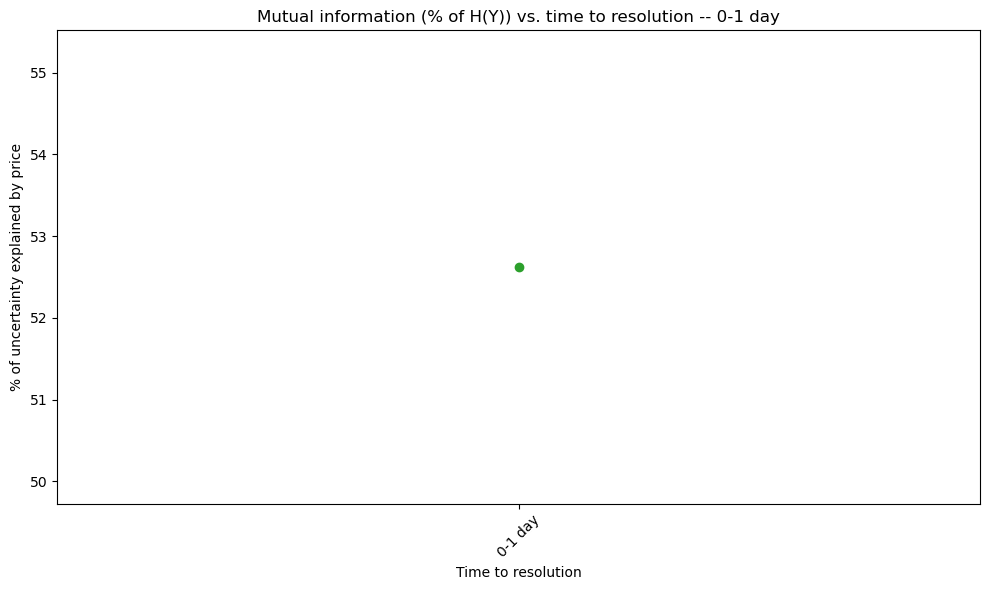

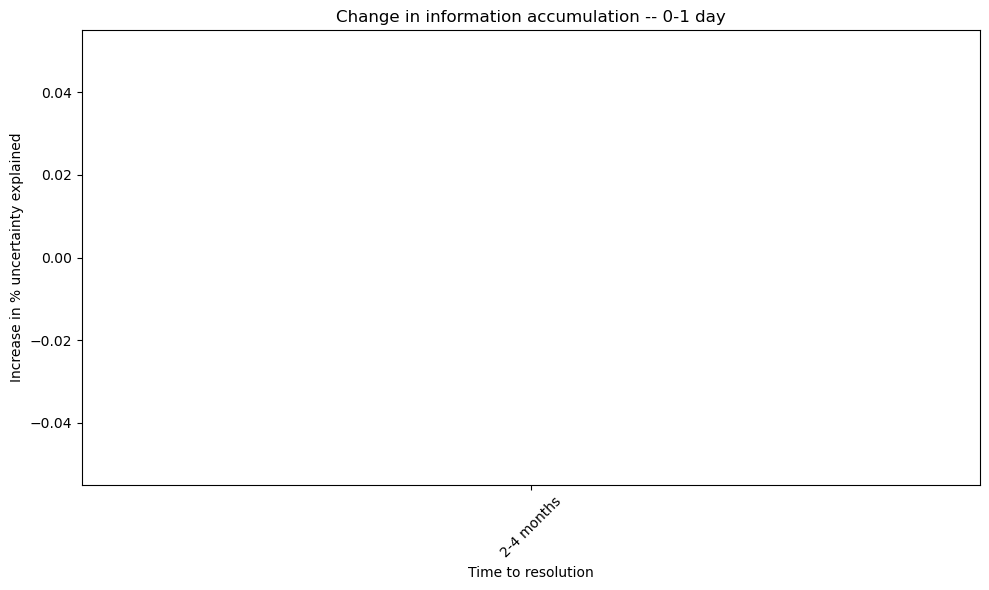

Cohort size: 1718 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                    NaN          NaN                        NaN
1-2 weeks                    NaN          NaN                        NaN
4-7 days                     NaN          NaN                        NaN
2-4 days                     NaN          NaN                        NaN
1-2 days                  0.7135       0.2294                    24.3283
0-1 day                   0.4927       0.4502                    47.7472


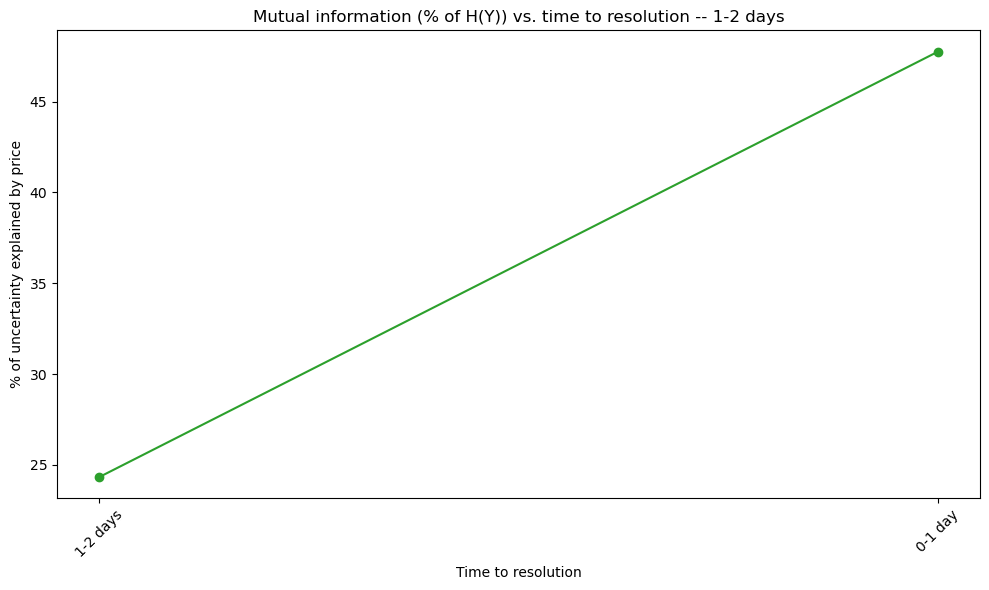

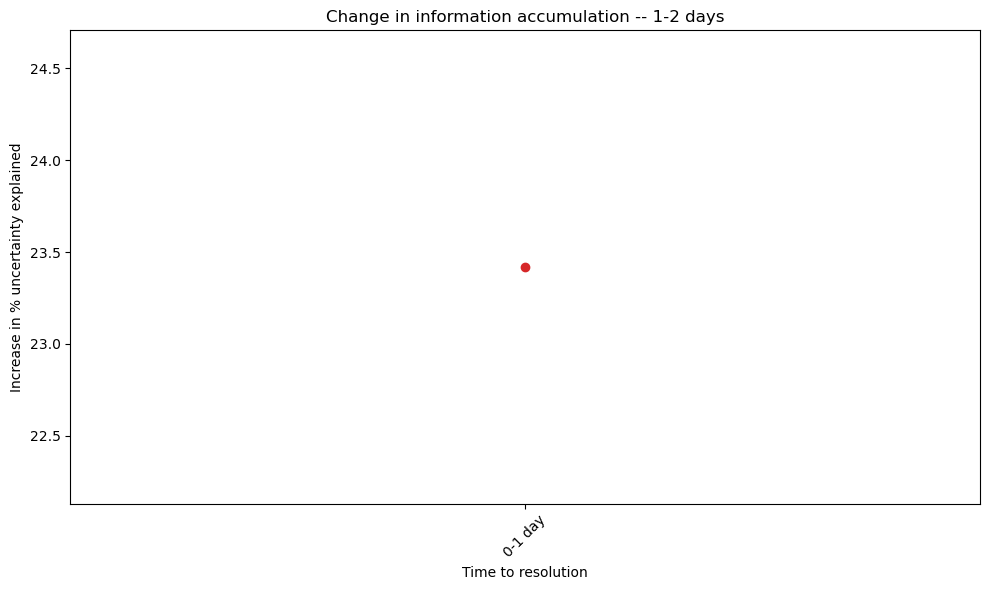

Cohort size: 3473 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                    NaN          NaN                        NaN
1-2 weeks                    NaN          NaN                        NaN
4-7 days                     NaN          NaN                        NaN
2-4 days                  0.6615       0.2440                    26.9486
1-2 days                  0.6378       0.2677                    29.5626
0-1 day                   0.4334       0.4721                    52.1410


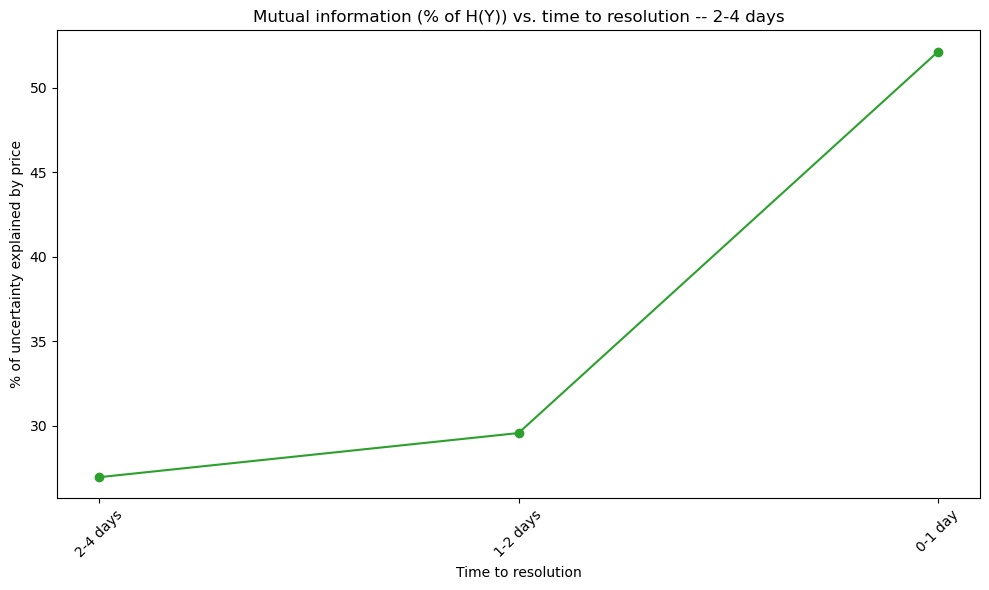

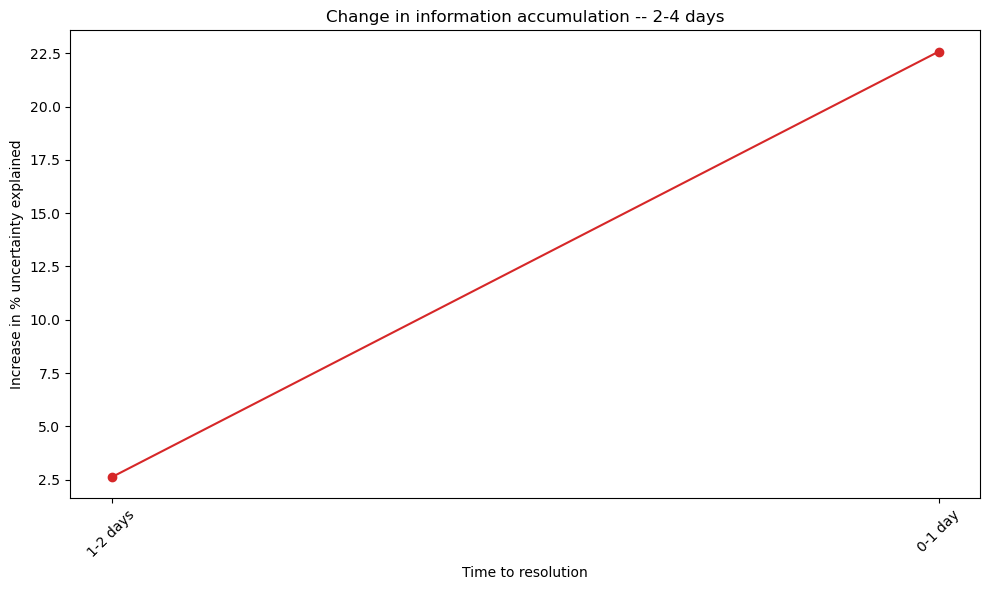

Cohort size: 5382 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                    NaN          NaN                        NaN
1-2 weeks                    NaN          NaN                        NaN
4-7 days                  0.6429       0.2506                    28.0509
2-4 days                  0.5623       0.3312                    37.0663
1-2 days                  0.4731       0.4204                    47.0479
0-1 day                   0.3372       0.5564                    62.2665


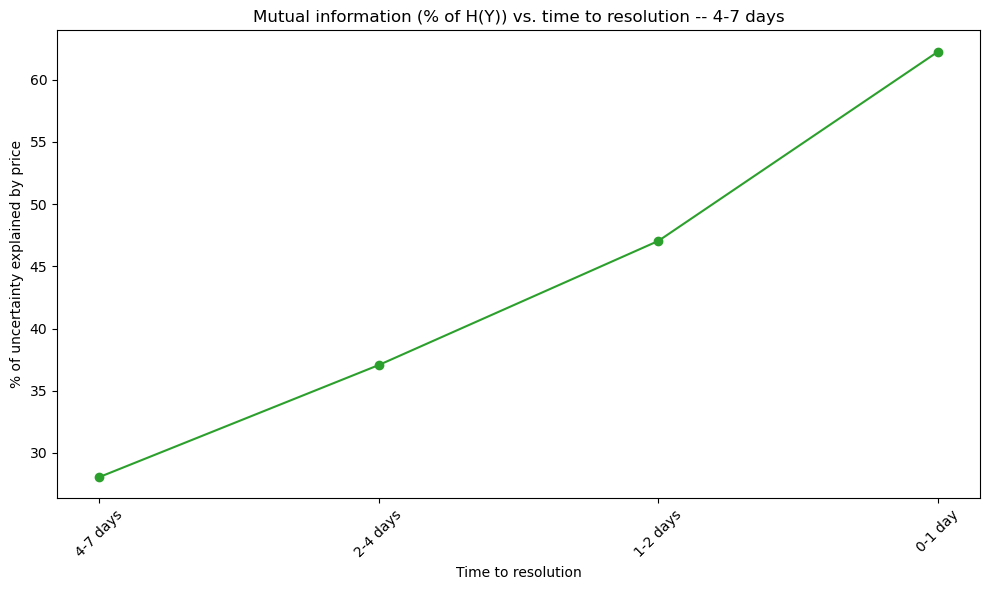

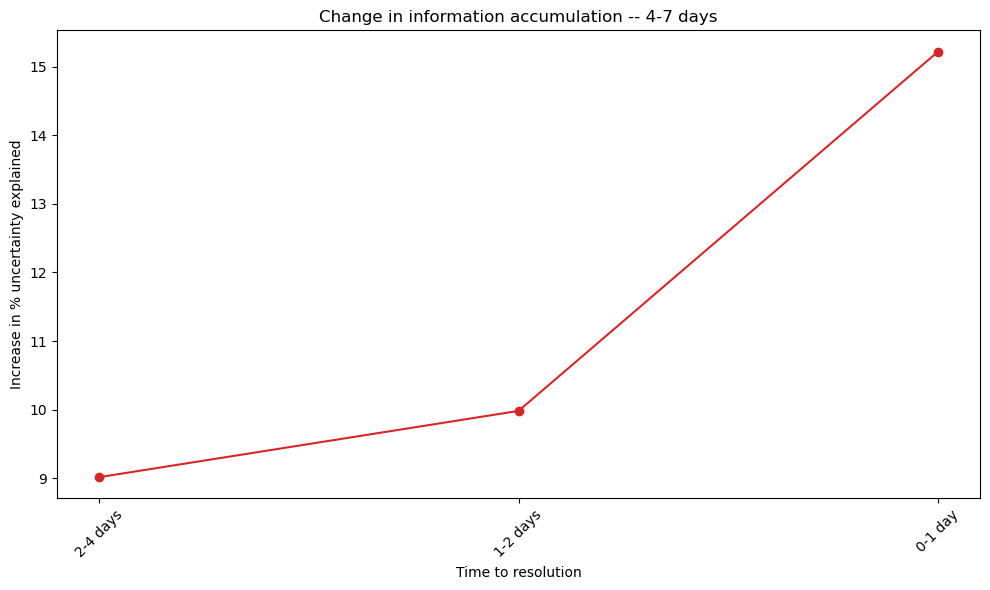

Cohort size: 17679 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                    NaN          NaN                        NaN
1-2 weeks                 0.7863       0.1207                    13.3063
4-7 days                  0.6557       0.2513                    27.7027
2-4 days                  0.5815       0.3255                    35.8831
1-2 days                  0.5088       0.3982                    43.9065
0-1 day                   0.3633       0.5437                    59.9439


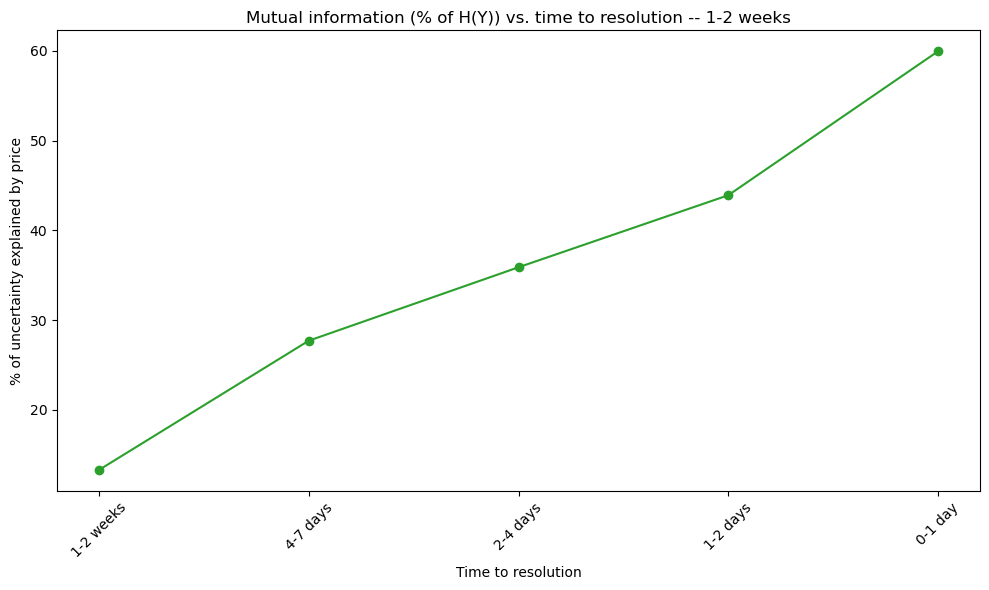

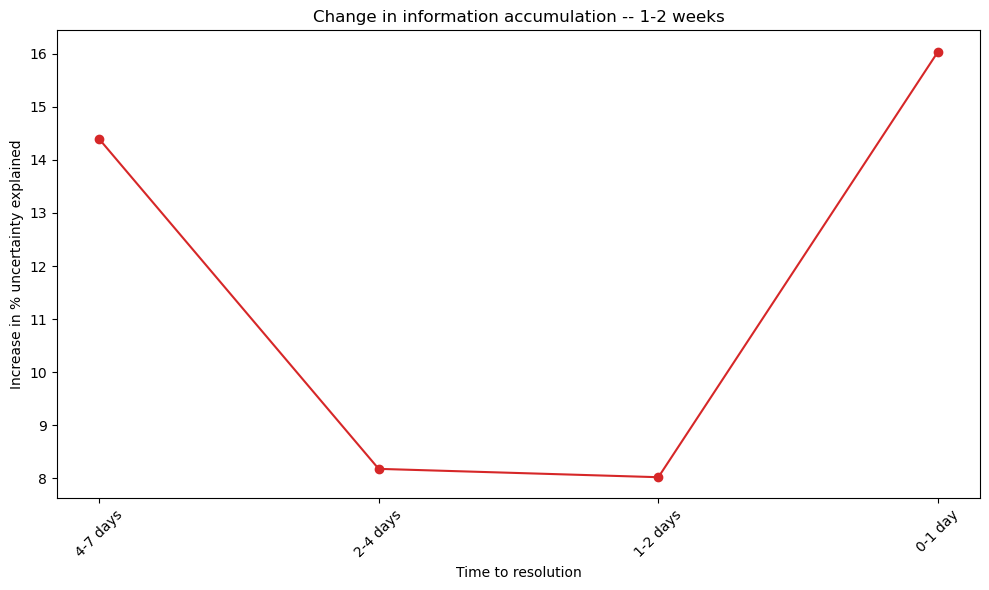

Cohort size: 6974 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                   NaN          NaN                        NaN
2-4 weeks                 0.6915       0.2263                    24.6594
1-2 weeks                 0.6537       0.2641                    28.7723
4-7 days                  0.6021       0.3157                    34.4000
2-4 days                  0.5640       0.3537                    38.5414
1-2 days                  0.5309       0.3869                    42.1538
0-1 day                   0.4192       0.4985                    54.3193


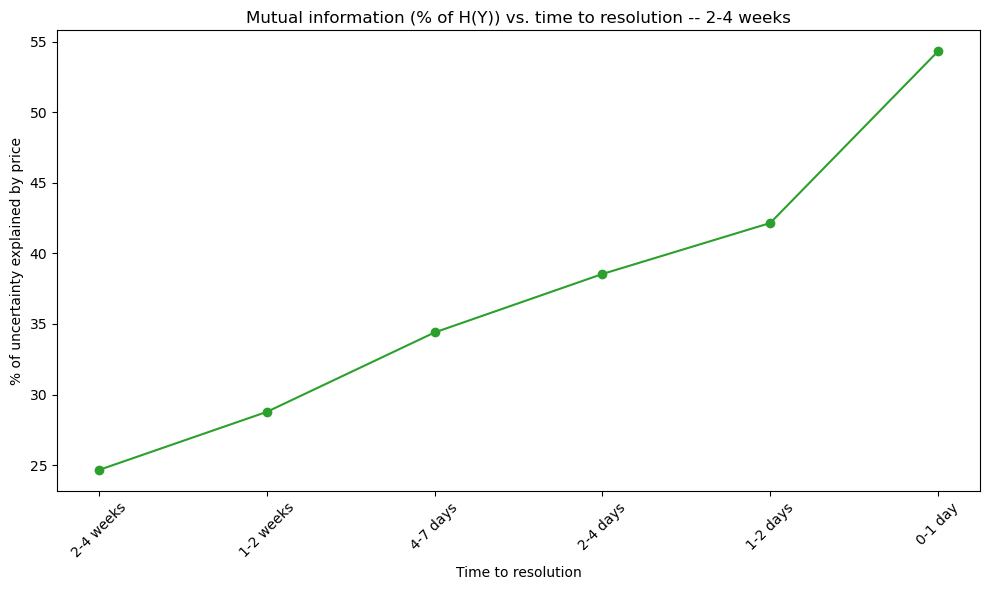

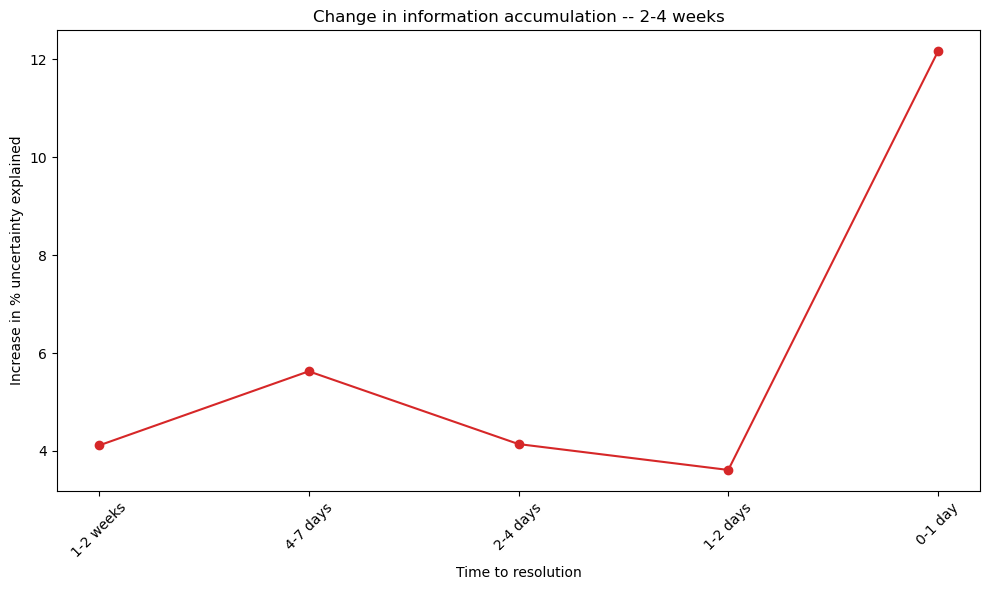

Cohort size: 5466 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                   NaN          NaN                        NaN
1-2 months                0.4857       0.2159                    30.7727
2-4 weeks                 0.4261       0.2755                    39.2711
1-2 weeks                 0.3596       0.3421                    48.7540
4-7 days                  0.3100       0.3917                    55.8217
2-4 days                  0.2750       0.4267                    60.8072
1-2 days                  0.2453       0.4564                    65.0445
0-1 day                   0.1768       0.5248                    74.7966


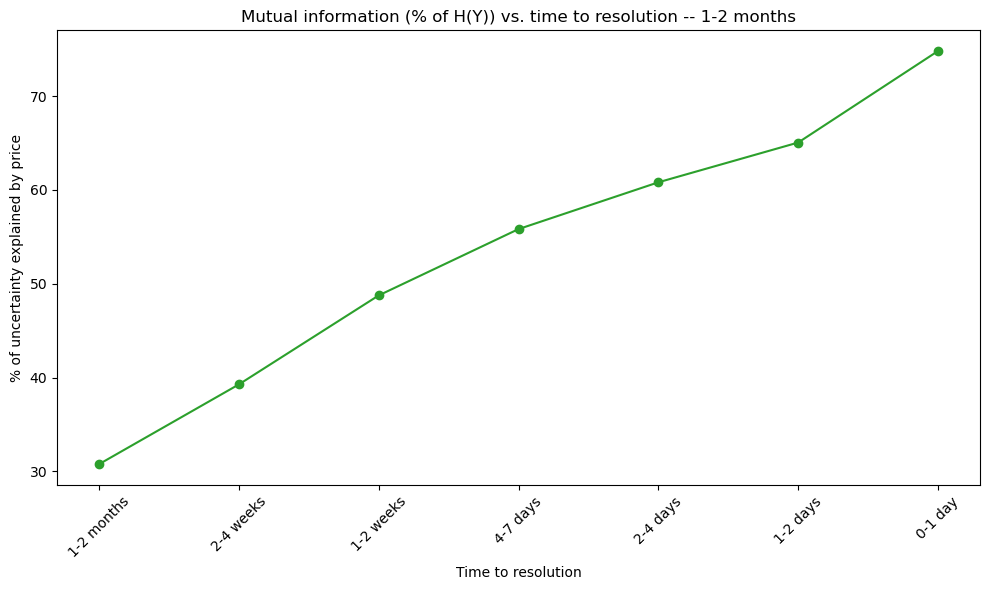

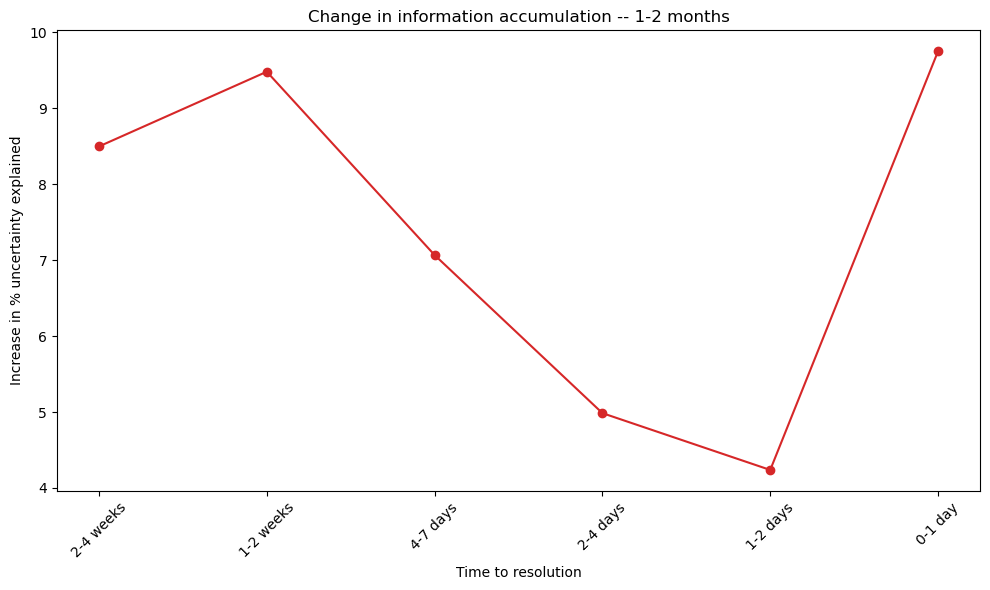

Cohort size: 3400 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                    NaN          NaN                        NaN
2-4 months                0.5098       0.2411                    32.1110
1-2 months                0.4176       0.3333                    44.3867
2-4 weeks                 0.3292       0.4217                    56.1634
1-2 weeks                 0.2785       0.4724                    62.9087
4-7 days                  0.2535       0.4975                    66.2472
2-4 days                  0.2264       0.5245                    69.8458
1-2 days                  0.2029       0.5480                    72.9790
0-1 day                   0.1487       0.6023                    80.2026


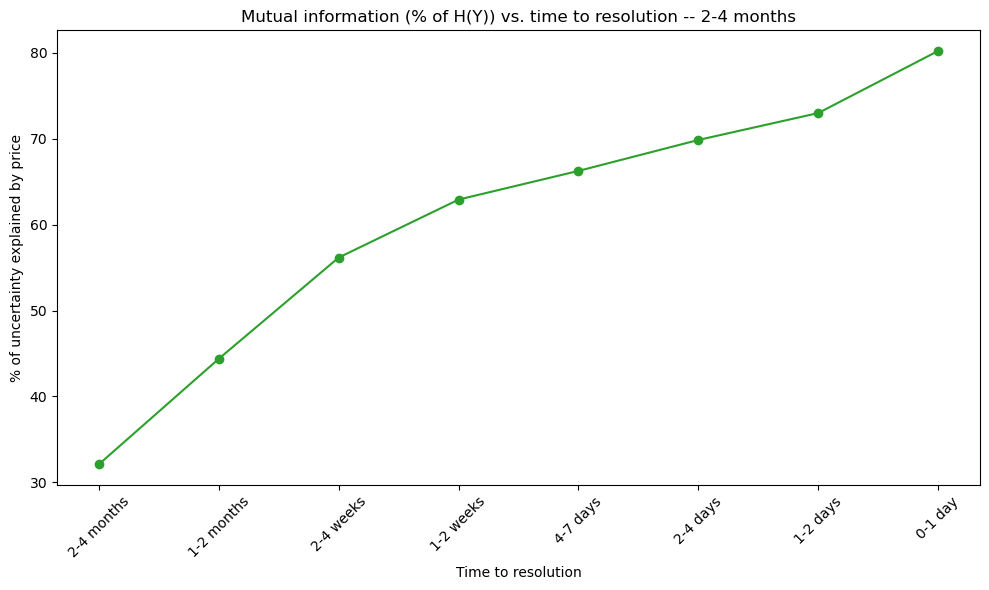

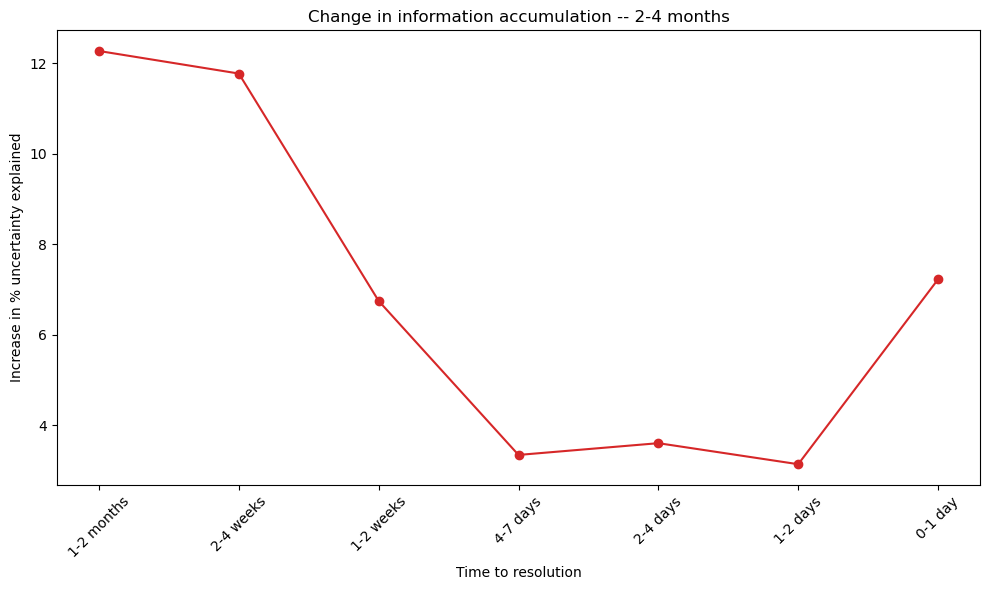

Cohort size: 4780 markets
Original sample: 49661 markets
            cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                 
>4 months                 0.3753       0.2208                    37.0412
2-4 months                0.3078       0.2883                    48.3672
1-2 months                0.2333       0.3628                    60.8595
2-4 weeks                 0.1773       0.4188                    70.2622
1-2 weeks                 0.1424       0.4536                    76.1021
4-7 days                  0.1169       0.4791                    80.3814
2-4 days                  0.0981       0.4980                    83.5475
1-2 days                  0.0874       0.5086                    85.3329
0-1 day                   0.0595       0.5365                    90.0146


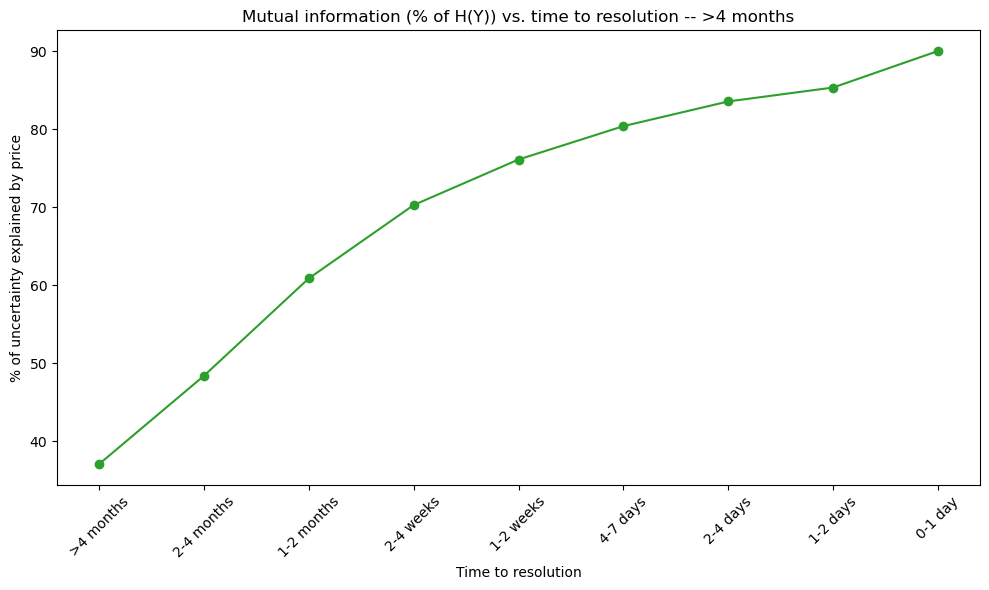

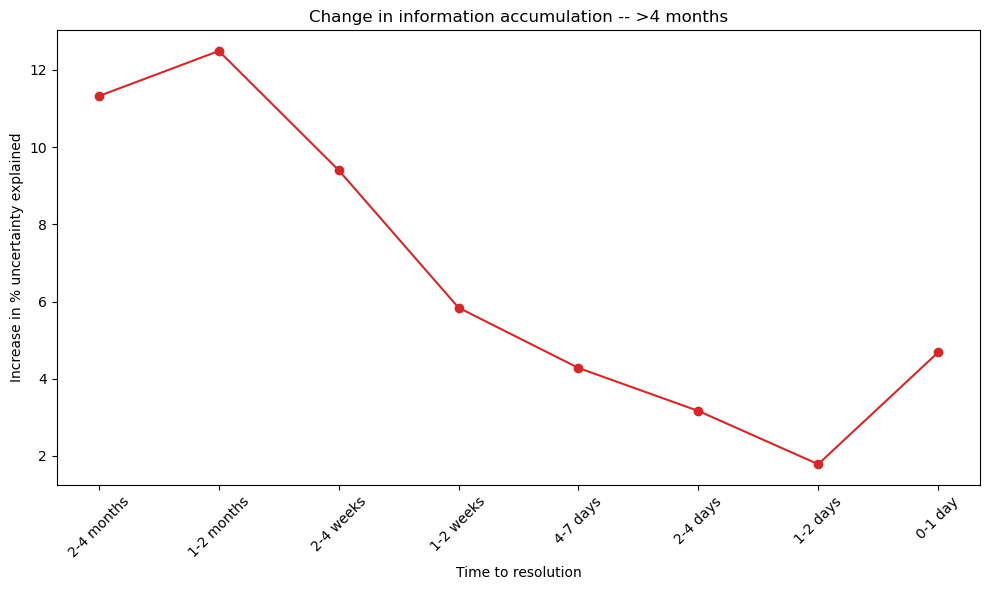

In [ ]:
# testing with "meaningful" intervals
time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf]

# so that we can read the meaningful intervals instead of just
# guessing from the total hours
time_labels = [
    "0-1 day",
    "1-2 days",
    "2-4 days",
    "4-7 days",
    "1-2 weeks",
    "2-4 weeks",
    "1-2 months",
    "2-4 months",
    ">4 months"
]

# across every time period segment, the conditional entropy monotonically falls
# as time to resolution falls
for period in time_labels:
    cohort = create_cohort(panel, period)
    decay, entropy = compute_decay_curve(cohort, label = period, both = False)

In [ ]:
### only if you're using custom ttr bins, since we need to remake the panel then

# evenly spaced
# testing it just bcz i think the prev curves are concave only cause of the uneven widths
time_edges = [0, 720, 1440, 2160, 2880, 3600, 4320, np.inf]
time_labels = [
    "0-30 days",
    "30-60 days",
    "60-90 days",
    "90-120 days",
    "120-150 days",
    "150-180 days",
    ">180 days"
]

panel1 = panel.copy() # we'll make the new ttr bins on panel1 and preserve the original panel
# add time to resolution column
time = panel1.index.get_level_values("t")
current_time = pd.to_datetime(time, unit="s", utc=True)

# ttr in hours will be more useful later for calculations
# even though its less readable
ttr = (panel1["closedTime"]-current_time).dt.total_seconds() / 3600

# you can see the 1hr gaps between entries due to the 60 min fidelity
insert_or_replace(panel1, nextpos(panel1, "closedTime"), "time_to_resolution", ttr)
panel1["time_to_resolution"] = panel1["time_to_resolution"].astype("float32")

# bin ttr into appropriate intervals defined above
ttrbins = pd.cut(
    panel1["time_to_resolution"],
    bins=time_edges,
    labels=time_labels,
    include_lowest=True,
    ordered=True # ensures that groupings respect the given order and doesnt go alphabetically or anything
)

insert_or_replace(panel1, nextpos(panel1, "time_to_resolution"), "ttr_bin", ttrbins)

# get the graphs
for period in time_labels:
    cohort = create_cohort(panel1, period, time_edges=time_edges, time_labels=time_labels)
    decay, entropy = compute_decay_curve(cohort, label = period, time_edges=time_edges, time_labels=time_labels, size=(10,4))

Cohort size: 29041 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                   NaN          NaN                        NaN
8-10 weeks                    NaN          NaN                        NaN
6-8 weeks                     NaN          NaN                        NaN
4-6 weeks                     NaN          NaN                        NaN
2-4 weeks                     NaN          NaN                        NaN
0-2 weeks                   0.614        0.295                    32.4539


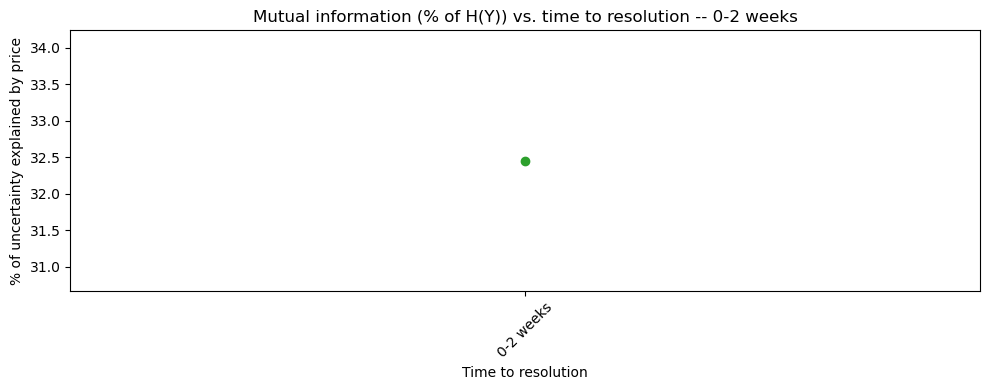

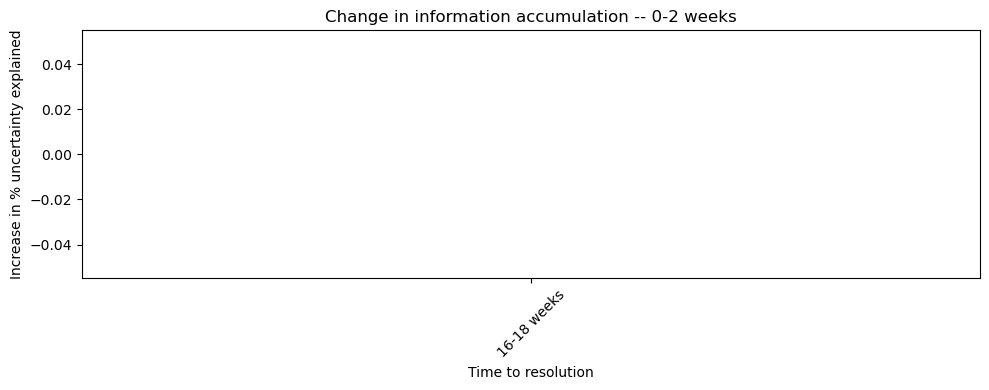

Cohort size: 5640 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                   NaN          NaN                        NaN
8-10 weeks                    NaN          NaN                        NaN
6-8 weeks                     NaN          NaN                        NaN
4-6 weeks                     NaN          NaN                        NaN
2-4 weeks                  0.7772       0.1697                    17.9183
0-2 weeks                  0.6598       0.2870                    30.3085


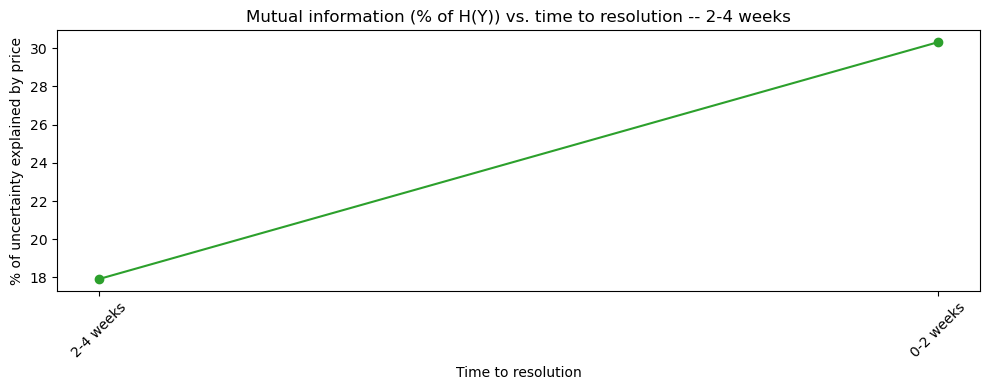

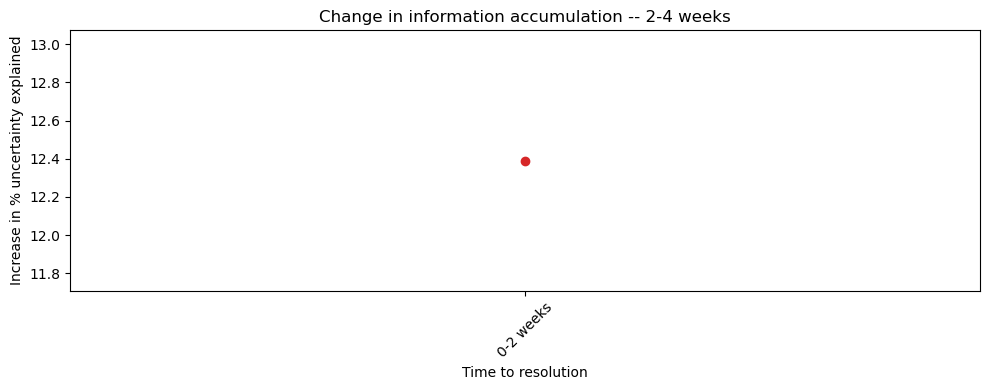

Cohort size: 4875 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                   NaN          NaN                        NaN
8-10 weeks                    NaN          NaN                        NaN
6-8 weeks                     NaN          NaN                        NaN
4-6 weeks                  0.5430       0.1445                    21.0155
2-4 weeks                  0.4600       0.2274                    33.0867
0-2 weeks                  0.3516       0.3358                    48.8494


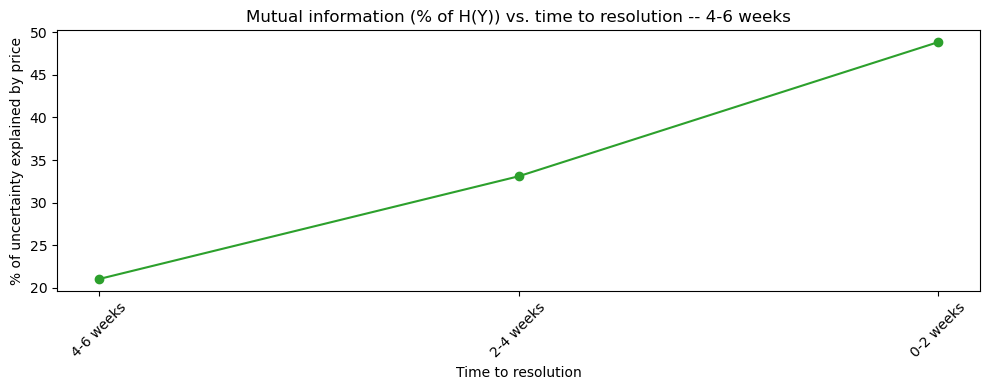

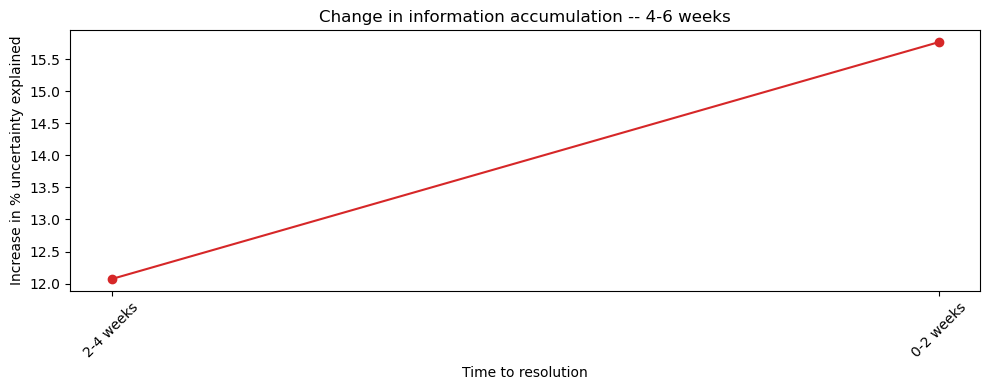

Cohort size: 1512 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                   NaN          NaN                        NaN
8-10 weeks                    NaN          NaN                        NaN
6-8 weeks                  0.4882       0.2676                    35.4038
4-6 weeks                  0.4381       0.3177                    42.0347
2-4 weeks                  0.3636       0.3922                    51.8896
0-2 weeks                  0.2634       0.4924                    65.1484


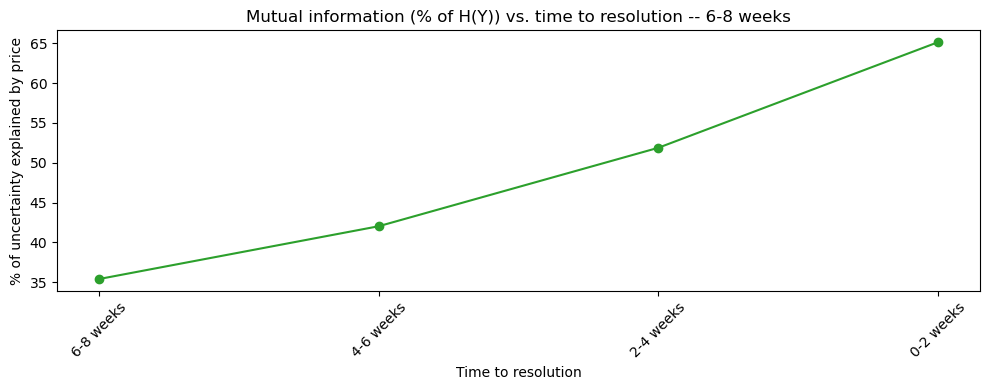

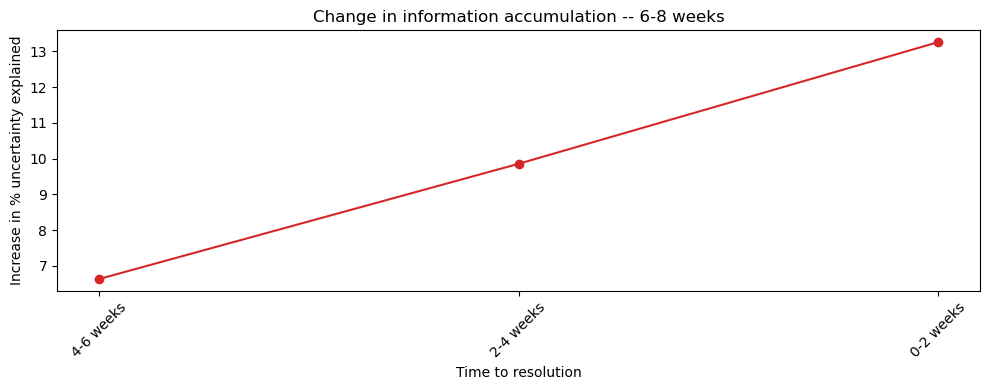

Cohort size: 1332 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                   NaN          NaN                        NaN
8-10 weeks                 0.4649       0.2668                    36.4624
6-8 weeks                  0.4283       0.3034                    41.4636
4-6 weeks                  0.3569       0.3749                    51.2300
2-4 weeks                  0.3242       0.4076                    55.6997
0-2 weeks                  0.2655       0.4663                    63.7212


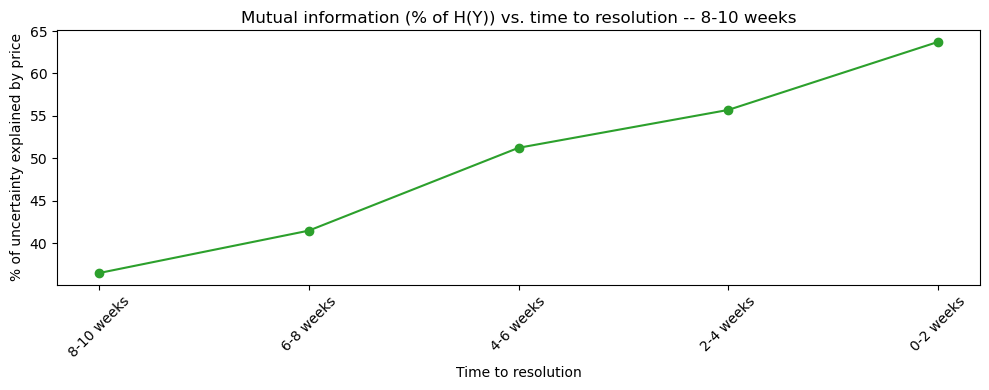

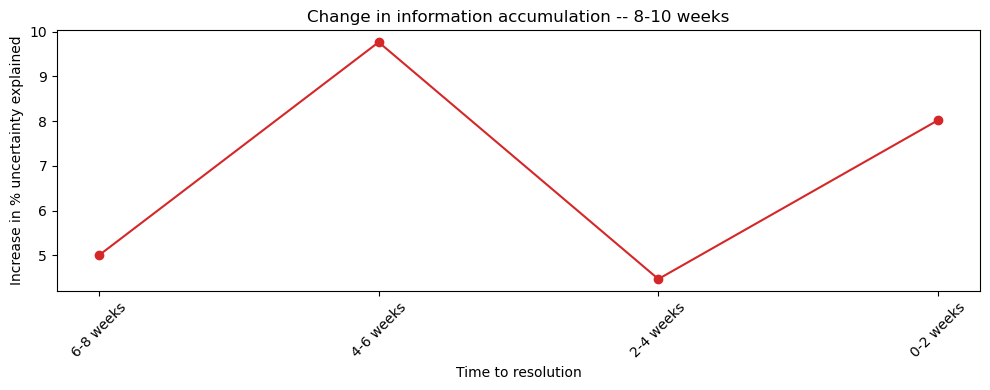

Cohort size: 1005 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                   NaN          NaN                        NaN
10-12 weeks                0.5758       0.2303                    28.5739
8-10 weeks                 0.5104       0.2957                    36.6872
6-8 weeks                  0.4799       0.3262                    40.4625
4-6 weeks                  0.4362       0.3699                    45.8823
2-4 weeks                  0.3738       0.4323                    53.6285
0-2 weeks                  0.3027       0.5034                    62.4521


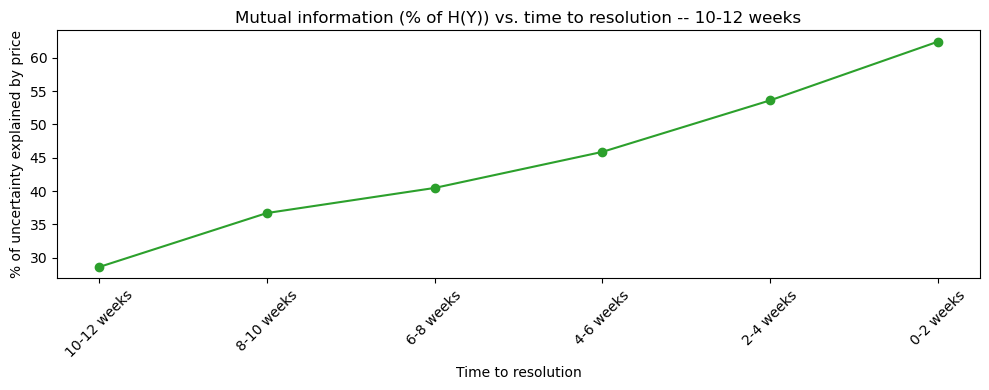

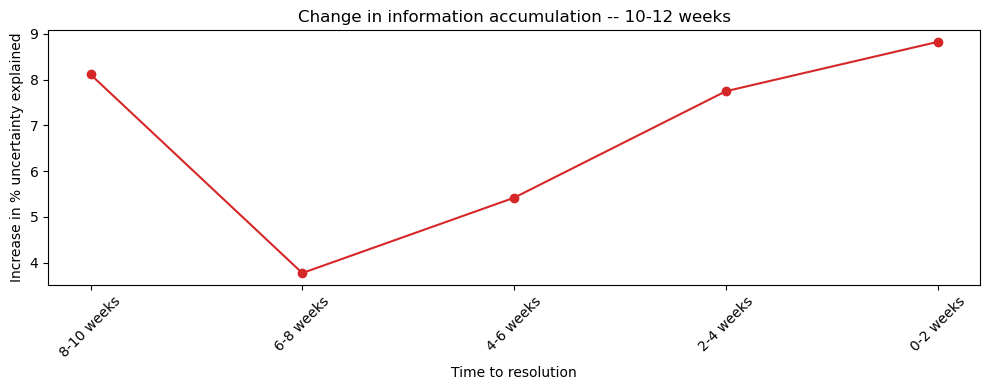

Cohort size: 632 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                   NaN          NaN                        NaN
12-14 weeks                0.5455       0.1656                    23.2834
10-12 weeks                0.5444       0.1666                    23.4309
8-10 weeks                 0.5074       0.2037                    28.6456
6-8 weeks                  0.4399       0.2712                    38.1351
4-6 weeks                  0.4085       0.3026                    42.5528
2-4 weeks                  0.3088       0.4023                    56.5725
0-2 weeks                  0.2144       0.4966                    69.8456


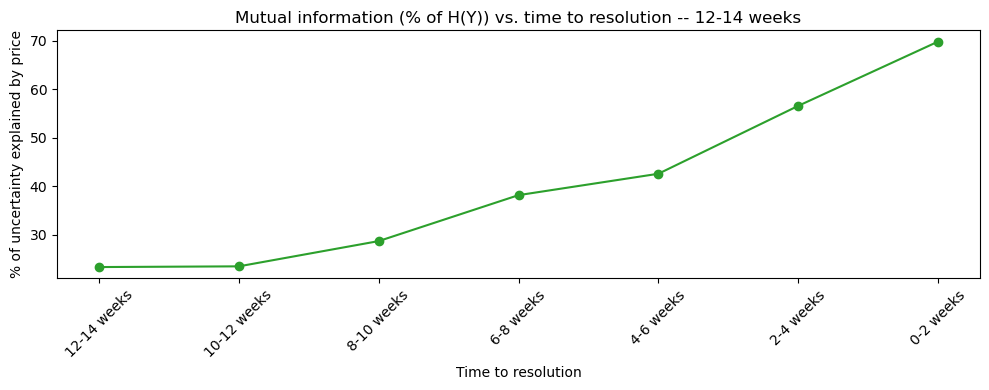

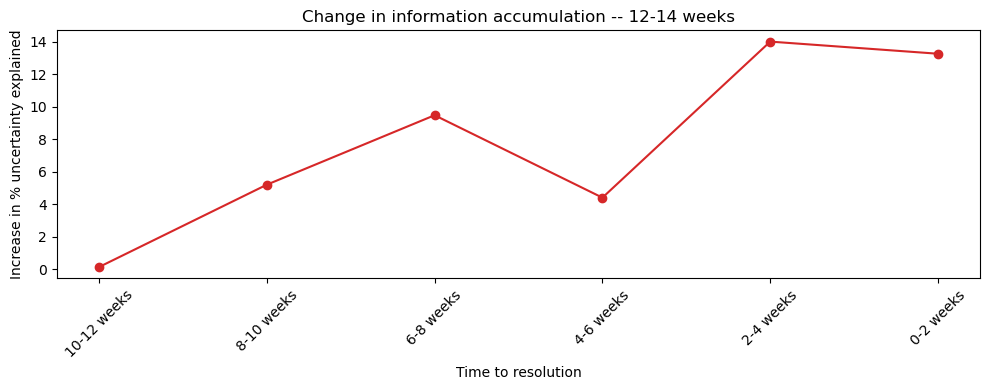

Cohort size: 470 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                   NaN          NaN                        NaN
14-16 weeks                0.4646       0.2173                    31.8665
12-14 weeks                0.4611       0.2209                    32.3875
10-12 weeks                0.3940       0.2880                    42.2305
8-10 weeks                 0.3646       0.3173                    46.5357
6-8 weeks                  0.3363       0.3457                    50.6898
4-6 weeks                  0.2745       0.4074                    59.7447
2-4 weeks                  0.2240       0.4579                    67.1467
0-2 weeks                  0.1451       0.5368                    78.7182


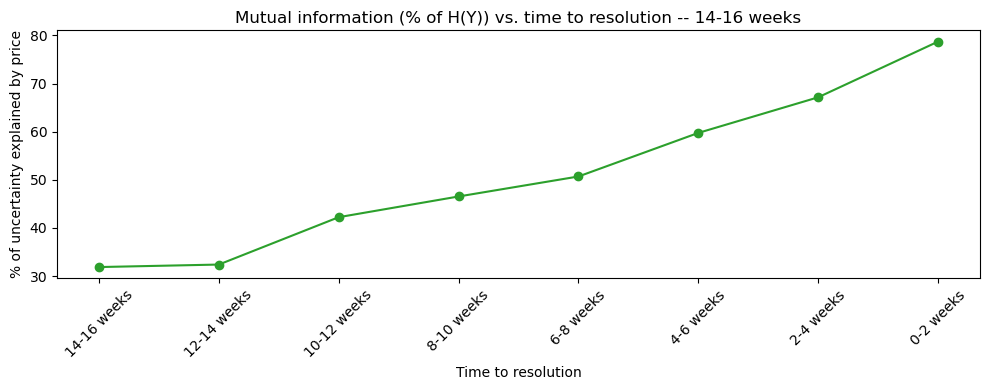

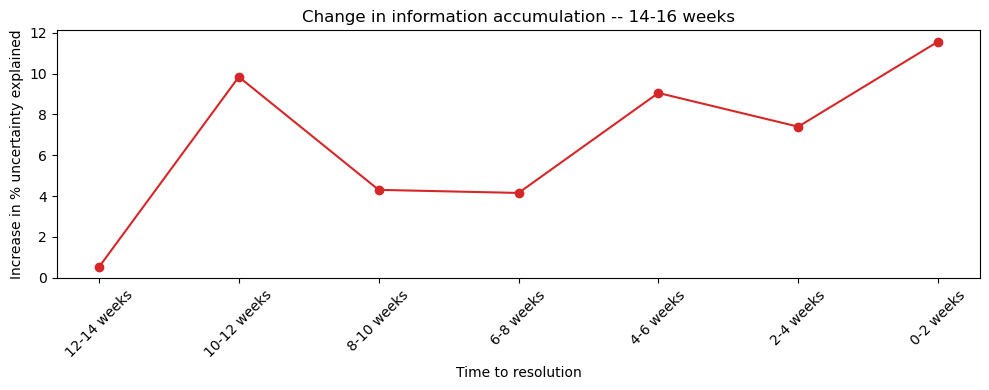

Cohort size: 536 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                     NaN          NaN                        NaN
16-18 weeks                0.5400       0.1922                    26.2505
14-16 weeks                0.5416       0.1906                    26.0360
12-14 weeks                0.4936       0.2387                    32.5918
10-12 weeks                0.4530       0.2792                    38.1306
8-10 weeks                 0.4128       0.3194                    43.6242
6-8 weeks                  0.3473       0.3849                    52.5654
4-6 weeks                  0.2844       0.4479                    61.1607
2-4 weeks                  0.2573       0.4749                    64.8586
0-2 weeks                  0.2024       0.5299                    72.3620


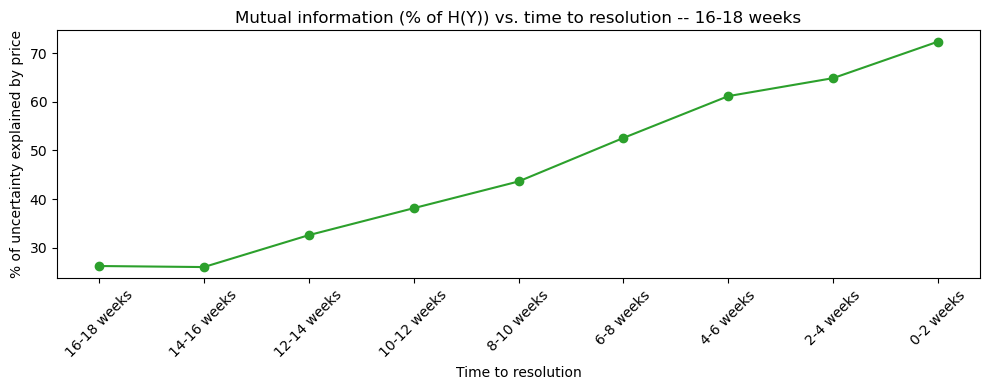

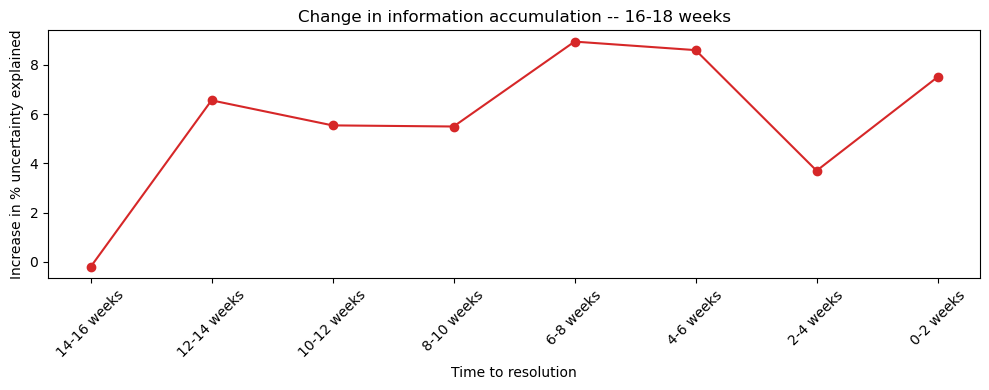

Cohort size: 4618 markets
Original sample: 49661 markets
             cond_entropy_given_t  mutual_info  pct_uncertainty_explained
ttr_bin                                                                  
>4 months                  0.3770       0.2154                    36.3614
16-18 weeks                0.3379       0.2545                    42.9645
14-16 weeks                0.3193       0.2731                    46.1015
12-14 weeks                0.3045       0.2879                    48.6060
10-12 weeks                0.2888       0.3036                    51.2442
8-10 weeks                 0.2631       0.3293                    55.5857
6-8 weeks                  0.2414       0.3510                    59.2484
4-6 weeks                  0.2122       0.3802                    64.1868
2-4 weeks                  0.1735       0.4189                    70.7099
0-2 weeks                  0.1209       0.4715                    79.5902


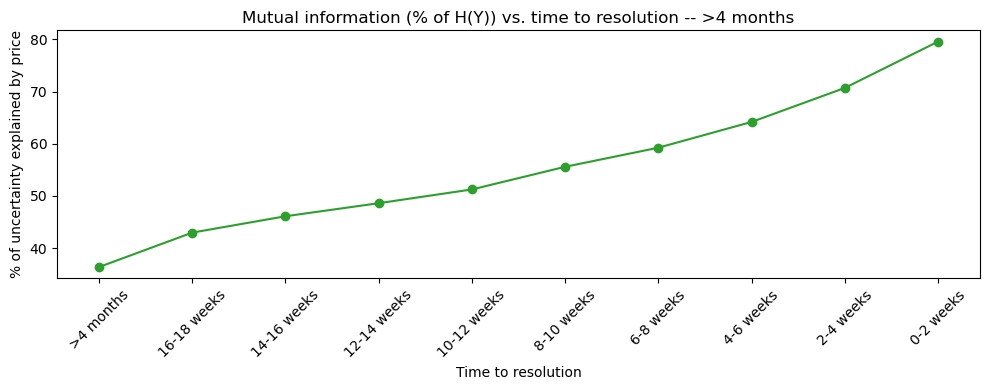

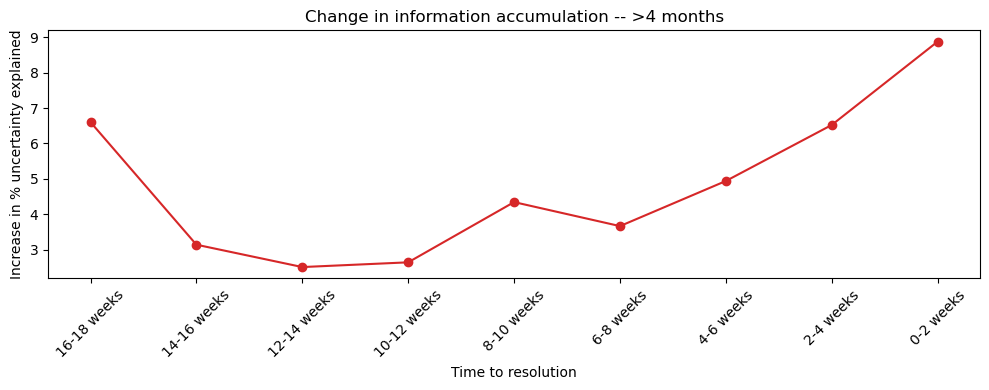

In [19]:
### only if you're using custom ttr bins, since we need to remake the panel then

# evenly spaced but 14 days now
# technically > 4 months is 126 days not 120 days since 120 isnt divisble by 14
# testing it just bcz i think the prev curves are concave only cause of the uneven widths
time_edges = [0, 336, 672, 1008, 1344, 1680, 2016, 2352, 2688, 3024, np.inf]
time_labels = [
    "0-2 weeks",
    "2-4 weeks",
    "4-6 weeks",
    "6-8 weeks",
    "8-10 weeks",
    "10-12 weeks",
    "12-14 weeks",
    "14-16 weeks",
    "16-18 weeks",
    ">4 months"
]

panel1 = panel.copy() # we'll make the new ttr bins on panel1 and preserve the original panel
# add time to resolution column
time = panel1.index.get_level_values("t")
current_time = pd.to_datetime(time, unit="s", utc=True)

# ttr in hours will be more useful later for calculations
# even though its less readable
ttr = (panel1["closedTime"]-current_time).dt.total_seconds() / 3600

# you can see the 1hr gaps between entries due to the 60 min fidelity
insert_or_replace(panel1, nextpos(panel1, "closedTime"), "time_to_resolution", ttr)
panel1["time_to_resolution"] = panel1["time_to_resolution"].astype("float32")

# bin ttr into appropriate intervals defined above
ttrbins = pd.cut(
    panel1["time_to_resolution"],
    bins=time_edges,
    labels=time_labels,
    include_lowest=True,
    ordered=True # ensures that groupings respect the given order and doesnt go alphabetically or anything
)

insert_or_replace(panel1, nextpos(panel1, "time_to_resolution"), "ttr_bin", ttrbins)

# get the graphs
for period in time_labels:
    cohort = create_cohort(panel1, period, time_edges=time_edges, time_labels=time_labels)
    decay, entropy = compute_decay_curve(cohort, label = period, time_edges=time_edges, time_labels=time_labels, size=(10,4), both = False)